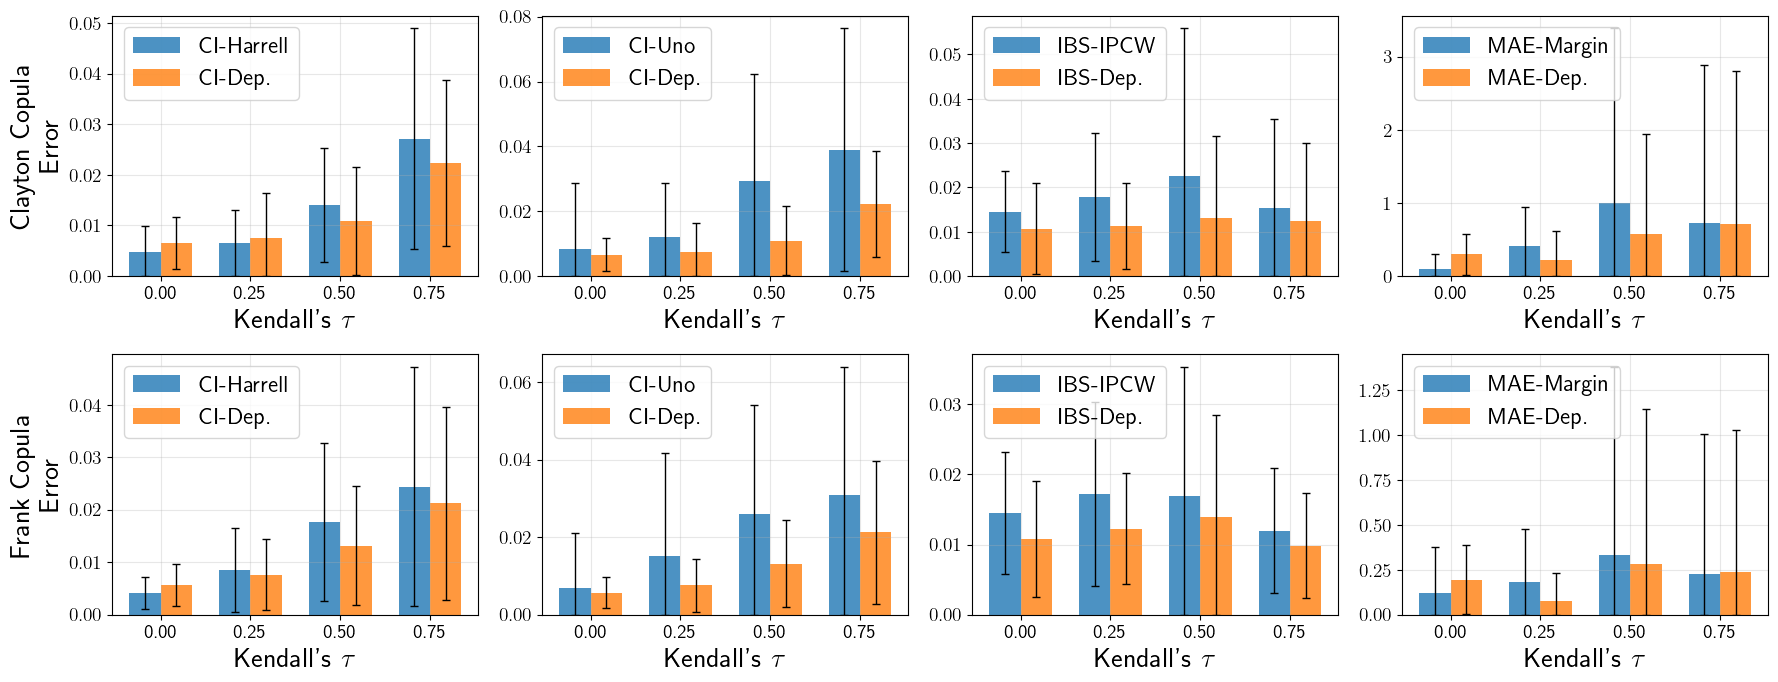

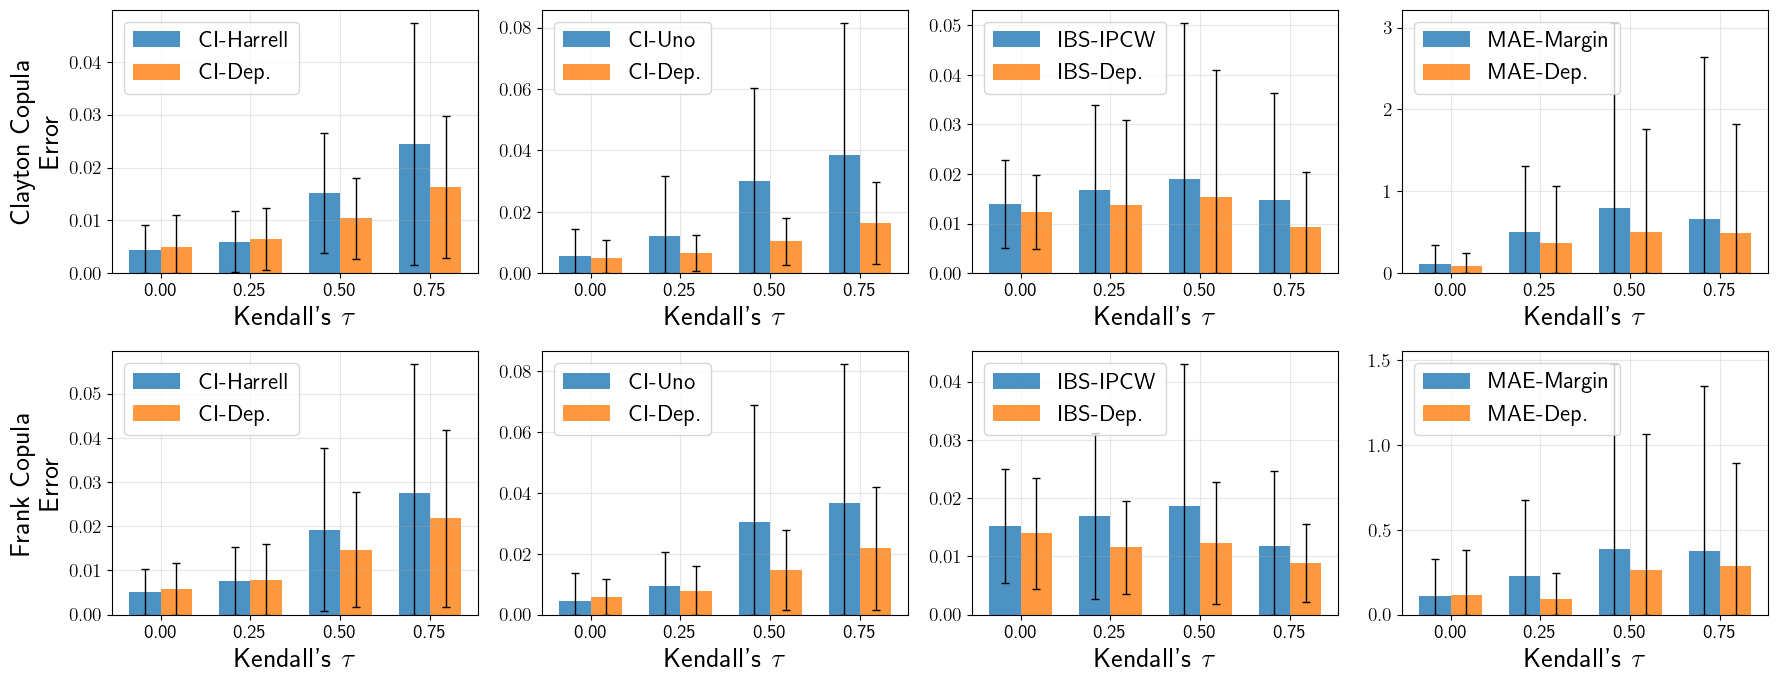

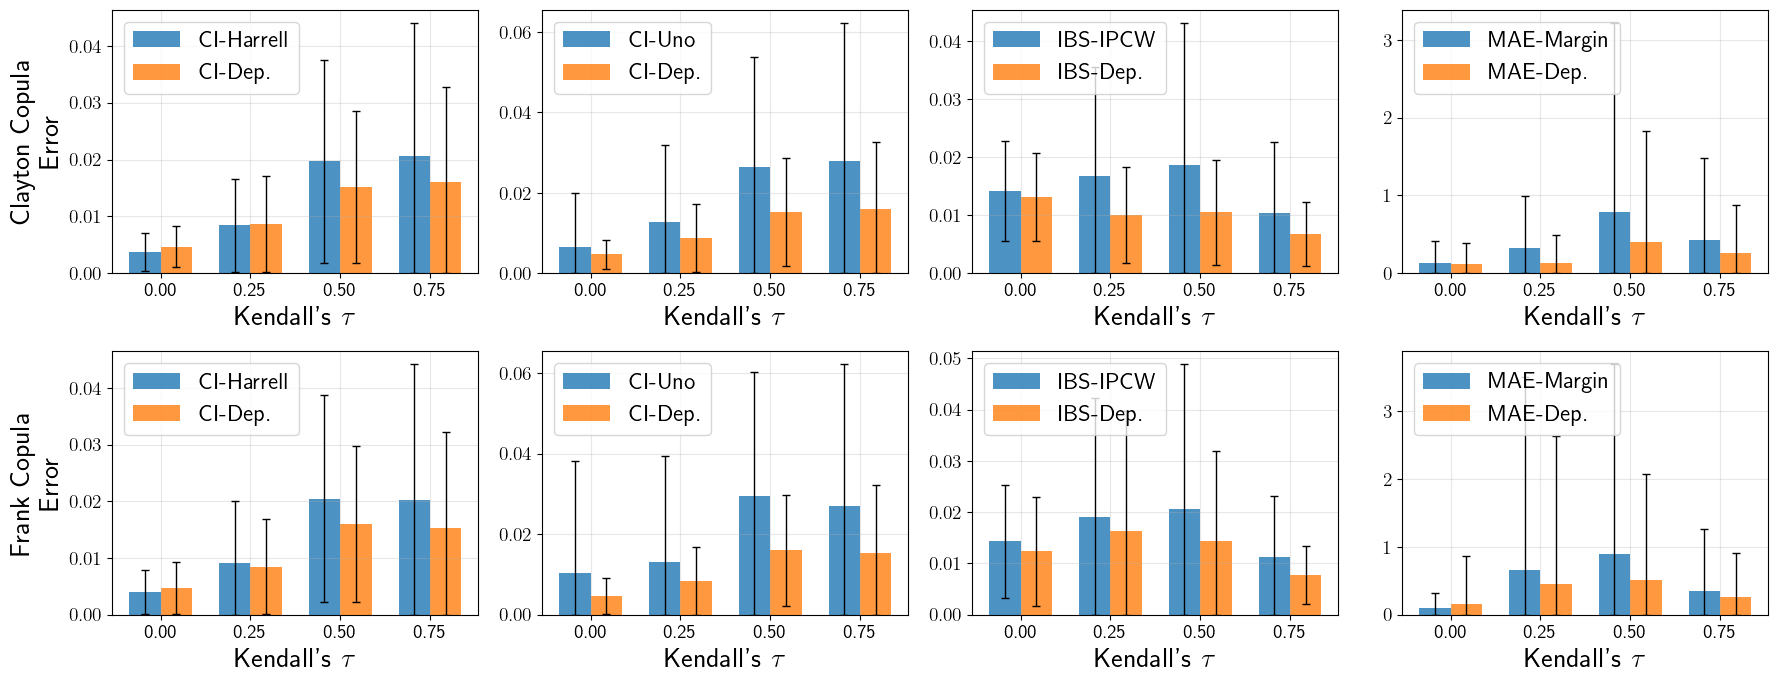

In [37]:
import numpy as np
import pandas as pd
import config as cfg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "font.size": 14.0,
    "legend.fontsize": "large",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

sigma_level = 1
z_threshold = 3

# Filter outliers
columns = [
    "ci_harrell_error", "ci_uno_error", "ci_dep_ipcw_error",
    "ibs_ipcw_error", "ibs_dep_bg_error",
    "mae_margin_error", "mae_dep_bg_error"
]
df = df[(np.abs((df[columns] - df[columns].mean()) / df[columns].std())
         < z_threshold).all(axis=1)]

# Keep only selected experiments
keep_exps = ["family", "dep", "gaussian"]
df = df[df["experiment"].isin(keep_exps)]
experiments = sorted(df["experiment"].unique())  # 3 experiments

# Group
grouped = df.groupby(["experiment", "copula_name", "k_tau", "n_samples"])
mean_errors = grouped.mean().reset_index()
std_errors = grouped.std().reset_index()

# Metrics to plot
error_columns = [
    ("ci_harrell_error", "ci_dep_ipcw_error", "CI-Harrell", "CI-Dep."),
    ("ci_uno_error", "ci_dep_ipcw_error", "CI-Uno", "CI-Dep."),
    ("ibs_ipcw_error", "ibs_dep_bg_error", "IBS-IPCW", "IBS-Dep."),
    ("mae_margin_error", "mae_dep_bg_error", "MAE-Margin", "MAE-Dep.")
]

copula_rows = {"clayton": 0, "frank": 1}
tau_keep = [0.0, 0.25, 0.5, 0.75]

# --- Plot: one figure per experiment ---
for exp in experiments:  # "family", "dep", "gaussian"
    fig, axs = plt.subplots(2, len(error_columns), figsize=(18, 8), sharey=False)

    for col_idx, (indep_metric, dep_metric, indep_name, dep_name) in enumerate(error_columns):
        for copula_name, row_idx in copula_rows.items():
            ax = axs[row_idx, col_idx]

            # Filter for this experiment, copula, and n_samples=10000
            mask = (
                (mean_errors["experiment"] == exp) &
                (mean_errors["copula_name"] == copula_name) &
                (mean_errors["n_samples"] == 10000) &
                (mean_errors["k_tau"].isin(tau_keep))
            )

            mean_data = mean_errors[mask].sort_values("k_tau")
            std_data  = std_errors[mask].sort_values("k_tau")

            tau_vals = mean_data["k_tau"].values
            x = np.arange(len(tau_vals))
            width = 0.35

            indep_vals = np.abs(mean_data[indep_metric].values)
            dep_vals   = np.abs(mean_data[dep_metric].values)
            indep_errs = np.abs(std_data[indep_metric].values)
            dep_errs   = np.abs(std_data[dep_metric].values)

            # Clip error bars so they don't drop below zero
            indep_lower = np.minimum(indep_errs, indep_vals)
            dep_lower   = np.minimum(dep_errs, dep_vals)

            indep_yerr = np.vstack([indep_lower, indep_errs])
            dep_yerr   = np.vstack([dep_lower, dep_errs])

            # Bars with less intrusive error bars
            ax.bar(x - width/2, indep_vals, width,
                yerr=indep_yerr, capsize=3,
                error_kw=dict(elinewidth=1, capsize=3, alpha=1.0),
                color="C0", alpha=0.8, label=indep_name)

            ax.bar(x + width/2, dep_vals, width,
                yerr=dep_yerr, capsize=3,
                error_kw=dict(elinewidth=1, capsize=3, alpha=1.0),
                color="C1", alpha=0.8, label=dep_name)

            # Axis formatting
            ax.set_xticks(x)
            ax.set_xticklabels([f"{t:.2f}" for t in tau_vals])
            ax.set_xlabel("Kendall's $\\tau$")
            ax.set_ylim(bottom=0)
            ax.grid(True, alpha=0.3)
            ax.legend(loc="upper left")

            if col_idx == 0:
                ax.set_ylabel(f"{copula_name.capitalize()} Copula\nError")

    plt.tight_layout(rect=[0, 0.07, 1, 0.95])

    plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_wrong_copula_{exp}.pdf",
                format="pdf", bbox_inches="tight")
    plt.show()